In [25]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent

sys.path.append(str(root_dir))


In [26]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

from dataset import RecordingDataset
from predictor import PredictorTransformer


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128
img_size = 128
in_channels = 3

vae = CNNVAE(in_channels=in_channels, latent_dim=latent_dim, img_size=img_size).to(device)
vae.load_state_dict(torch.load('../embedder/vae-doom.pt', map_location=device))
vae.eval()

CNNVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=16384, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=16384, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=16384, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=

In [28]:
obs = torch.tensor(np.transpose(np.load('../try/doom-obs.npy').astype(np.float32) / 255.0, (0, 3, 1, 2)))
act = np.array(np.load('../try/doom-act.npy', allow_pickle=True), dtype=np.float32)

In [29]:
obs = vae.reparameterize(*vae.encode(obs)).squeeze().detach()

In [ ]:
act[:-1]

np.float32(1.0)

In [129]:
class DoomDataset(torch.utils.data.Dataset):
    def __init__(self, obs, act, seq_len=8):
        self.obs = obs
        self.actions = act
        self.seq_len = seq_len

        assert len(self.obs) == len(self.actions) + 1, (
            f"Длина obs ({len(self.obs)}) должна быть на 1 больше длины actions ({len(self.actions)})"
        )
        assert len(self.obs) > self.seq_len, (
            f"Всего наблюдений {len(self.obs)}, нужно seq_len+1 = {seq_len+1}"
        )

        self.num_samples = len(self.obs) - self.seq_len - 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        t = idx
        obs_window = self.obs[t : t + self.seq_len]
        act_window = self.actions[t : t + self.seq_len]
        # target — сдвиг на +1
        target_window = self.obs[t + 1 : t + self.seq_len + 1]
        actions = torch.from_numpy(act_window).long()
        return obs_window, actions.unsqueeze(1), torch.tensor(target_window)

In [130]:
dataset = DoomDataset(
    obs=obs,
    act=act[:-1]/6,
    seq_len=340
)

In [131]:
train_loader = DataLoader(dataset, batch_size=8)

In [132]:
len(train_loader)

1294

In [133]:
predictor = PredictorTransformer(128, 32, 128, 1, 4, 4, 340, 5)

In [134]:
from torchinfo import summary

In [135]:
summary(predictor)

Layer (type:depth-idx)                   Param #
PredictorTransformer                     --
├─Linear: 1-1                            64
├─Linear: 1-2                            20,608
├─SinusoidalPositionalEncoding: 1-3      --
├─ModuleList: 1-4                        --
│    └─TransformerBlock: 2-1             --
│    │    └─LayerNorm: 3-1               256
│    │    └─MultiHeadAttention: 3-2      66,048
│    │    └─Dropout: 3-3                 --
│    │    └─LayerNorm: 3-4               256
│    │    └─SimpleFFN: 3-5               131,712
│    │    └─Dropout: 3-6                 --
│    └─TransformerBlock: 2-2             --
│    │    └─LayerNorm: 3-7               256
│    │    └─MultiHeadAttention: 3-8      66,048
│    │    └─Dropout: 3-9                 --
│    │    └─LayerNorm: 3-10              256
│    │    └─SimpleFFN: 3-11              131,712
│    │    └─Dropout: 3-12                --
│    └─TransformerBlock: 2-3             --
│    │    └─LayerNorm: 3-13              256


In [136]:
optimizer = optim.Adam(predictor.parameters(), lr=1e-4)

In [137]:
from tqdm import tqdm

In [138]:
torch.pi

3.141592653589793

In [139]:
import math

In [140]:
def mdn_loss(pi, mu, sigma, target):
    """
    Negative log-likelihood гауссовой смеси.

    Args:
        pi:     (B, S, n_gaussians)
        mu:     (B, S, n_gaussians, z_dim)
        sigma:  (B, S, n_gaussians, z_dim)
        target: (B, S, z_dim)
    """
    z_dim = target.size(-1)
    target = target.unsqueeze(-2)                                    # (B, S, 1, z_dim)

    const = -0.5 * z_dim * math.log(2 * math.pi)
    log_prob = const - sigma.log().sum(dim=-1) \
               - 0.5 * ((target - mu) / sigma).pow(2).sum(dim=-1)   # (B, S, n_gaussians)

    log_weighted = log_prob + (pi + 1e-10).log()                    # (B, S, n_gaussians)
    nll = -torch.logsumexp(log_weighted, dim=-1)                    # (B, S)

    return nll.mean()

In [141]:
A.shape

torch.Size([8, 340])

In [142]:
predictor.train()
for epoch in range(50):
    total_loss_epoch = 0
    for batch in tqdm(train_loader):
        Z_in = batch[0].to(device)
        A = batch[1].to(torch.float).to(device)
        Z_tgt = batch[2].to(device)


        optimizer.zero_grad()
        pi, mu, sigma = predictor(Z_in, A)
        
        loss = mdn_loss(pi, mu, sigma, Z_tgt)
        
        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()

    avg_loss = total_loss_epoch / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{50}, Average Loss: {avg_loss:.4f}")

  0%|          | 0/1294 [00:00<?, ?it/s]/var/folders/48/wvfw_hqj02x66nvb7tyts8bw0000gn/T/ipykernel_80660/1901730739.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return obs_window, actions.unsqueeze(1), torch.tensor(target_window)
100%|██████████| 1294/1294 [04:31<00:00,  4.77it/s]


Epoch 1/50, Average Loss: 22.0648


100%|██████████| 1294/1294 [04:38<00:00,  4.65it/s]


Epoch 2/50, Average Loss: 19.8916


100%|██████████| 1294/1294 [04:46<00:00,  4.51it/s]


...

Epoch 10/50, Average Loss: 17.0396


100%|██████████| 1294/1294 [04:16<00:00,  5.04it/s]


Epoch 11/50, Average Loss: 16.8271


 37%|███▋      | 482/1294 [01:35<02:40,  5.06it/s]


KeyboardInterrupt: 

In [14]:
Z_in.shape

torch.Size([8, 64, 32])

In [15]:
A.shape

torch.Size([8, 64, 3])

In [16]:
reward_tgt.shape

torch.Size([8, 64, 1])

In [143]:
data_t = next(iter(train_loader))
acts = []
zets = []
outs = []
for z, a, in zip(data_t[0][0][:8], data_t[1][0][:8]):
    acts.append(a)
    zets.append(z)
    A = torch.stack(acts).unsqueeze(0).to(torch.float32)
    Z = torch.stack(zets).unsqueeze(0)
    pi, mu, sigma = predictor(Z, A)
    z = predictor.sample(pi, mu, sigma)
    outs.append(z[:, -1, :])

/var/folders/48/wvfw_hqj02x66nvb7tyts8bw0000gn/T/ipykernel_80660/1901730739.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return obs_window, actions.unsqueeze(1), torch.tensor(target_window)


In [144]:
torch.stack(outs).squeeze(1).shape

torch.Size([8, 128])

/var/folders/48/wvfw_hqj02x66nvb7tyts8bw0000gn/T/ipykernel_80660/1901730739.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return obs_window, actions.unsqueeze(1), torch.tensor(target_window)


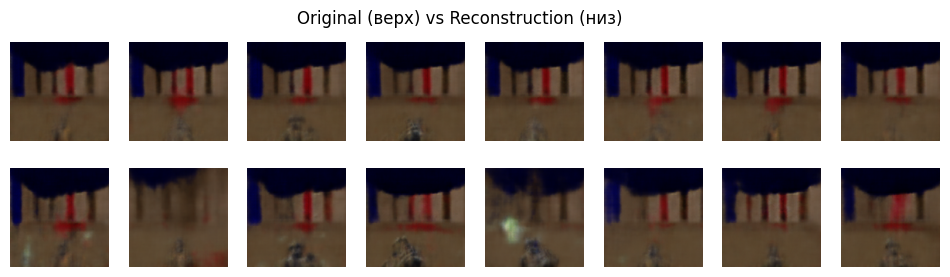

In [145]:
vae.eval()
with torch.no_grad():
    true_z = next(iter(train_loader))[0][0][:8].to(device)
    pred_z = torch.stack(outs).squeeze(1).to(device)
    recon_true_x = vae.decode(true_z)
    recon_prex_x = vae.decode(pred_z)
    
    test_x_cpu = recon_true_x.cpu().numpy()
    recon_x_cpu = recon_prex_x.cpu().numpy()

    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(8):
        axes[0, i].imshow(np.transpose(test_x_cpu[i], (1, 2, 0)))
        axes[0, i].axis('off')
        axes[1, i].imshow(np.transpose(recon_x_cpu[i], (1, 2, 0)))
        axes[1, i].axis('off')
    plt.suptitle("Original (верх) vs Reconstruction (низ)")
    plt.show()

In [146]:
torch.save(predictor.state_dict(), "predictor_doom_mdn.pt")

In [26]:
torch.randn(1, 32, dtype=torch.float32)

tensor([[ 0.4637, -1.4288, -0.2586, -1.3323,  0.6880, -0.0938,  1.1090, -1.3577,
         -0.5289, -0.3311, -0.6953,  0.3115, -1.8505,  1.7236,  1.8644, -0.2962,
          1.2820,  1.0525, -0.4044, -0.2356, -0.3161, -1.1641, -0.0862, -0.6540,
          0.6764, -0.6931, -0.0344,  1.3946, -1.3854, -1.2635,  0.0299,  0.1003]])